# Getting Started: Opacity and CIA Data

Every TauREx simulation is driven by tabulated molecular data — cross-sections that encode how strongly each gas absorbs at each wavelength, and CIA tables for the continuum opacity of background gases. This notebook gets those files in place so that the rest of the series can focus entirely on building and interpreting atmospheric models.

Two kinds of external data are needed:
- **Molecular cross-sections (opacities)** — wavelength-dependent absorption coefficients for each gas species (e.g., H₂O, CH₄), distributed in HDF5 format by communities such as [ExoMol](https://www.exomol.com) and [HITRAN](https://hitran.org/).
- **Collision-Induced Absorption (CIA) files** — continuum opacity from molecular pairs (e.g., H₂–H₂, H₂–He), important for the spectral baseline in hydrogen-dominated atmospheres.

TauREx supports several cross-section formats: [ExoMolOP](https://www.aanda.org/articles/aa/full_html/2021/02/aa38350-20/aa38350-20.html) HDF5, legacy TauREx 2 pickle, and [ExoTransmit](https://github.com/elizakempton/Exo_Transmit). For CIA, both HITRAN `.cia` and legacy `.db` formats are accepted, and additional formats can be added through plugins.

> **A note on data provenance.** TauREx provides software to read and analyse these datasets, but the files themselves are third-party products. The opacity files downloaded below come from [ExoMol](https://www.exomol.com) and the CIA files from [HITRAN](https://hitran.org/); they are not created, owned, or warranted by the TauREx team.

Once the files are in place, TauREx's caching system discovers them automatically — path configuration is a one-time step. More information about input-file conventions is [here](../user/taurex/inputfile.rst), and global path settings are [here](../user/taurex/global.rst).

In [1]:
from _shared import CIA_DIR, PROJECT_ROOT, SRC_DIR, TMP_DIR, XSEC_DIR, ensure_opacity_data

print(f'Project root: {PROJECT_ROOT}')
print(f'Source directory: {SRC_DIR}')
print(f'Temporary data directory: {TMP_DIR}')
print(f'Cross-sections directory: {XSEC_DIR}')
print(f'CIA directory: {CIA_DIR}')

Project root: /home/simone/Dropbox/eScience_projects/TauRex/taurex3
Source directory: /home/simone/Dropbox/eScience_projects/TauRex/taurex3/src
Temporary data directory: /home/simone/Dropbox/eScience_projects/TauRex/taurex3/examples/tmp
Cross-sections directory: /home/simone/Dropbox/eScience_projects/TauRex/taurex3/examples/tmp/xsec
CIA directory: /home/simone/Dropbox/eScience_projects/TauRex/taurex3/examples/tmp/cia


## Downloading Opacity Files

The `ensure_opacity_data` helper fetches a small example dataset if it is not already present locally, then registers the download directory with the TauREx caches. Existing files are reused rather than re-downloaded, so running this cell a second time is instant.

In [2]:
ensure_opacity_data(download=True)

xsec_files = sorted(path.name for path in XSEC_DIR.glob('*.h5'))
cia_files = sorted(path.name for path in CIA_DIR.glob('*.cia'))

print('Opacity data are available and the TauREx caches are configured.')
print(f'Found {len(xsec_files)} cross-section files: {xsec_files}')
print(f'Found {len(cia_files)} CIA files: {cia_files}')

Opacity data are available and the TauREx caches are configured.
Found 4 cross-section files: ['12C-16O2__UCL-4000.R15000_0.3-50mu.xsec.TauREx.h5', '12C-1H4__MM.R15000_0.3-50mu.xsec.TauREx.h5', '14N-1H3__CoYuTe.R15000_0.3-50mu.xsec.TauREx.h5', '1H2-16O__POKAZATEL__R15000_0.3-50mu.xsec.TauREx.h5']
Found 2 CIA files: ['H2-H2_eq_2018.cia', 'H2-He_eq_2011.cia']


## Verifying the Cache

Once the cache is configured, `OpacityCache` reports the molecules it found. This is a useful sanity check before building a model — if a molecule does not appear here, it will not be available as an active gas in [Temperature, pressure, and chemistry](https://escience-taurex.github.io/taurex3/examples/02_atmosphere_components.html).

In [3]:
from taurex.cache import OpacityCache

print('Molecules discovered by the opacity cache:')
OpacityCache().find_list_of_molecules()

Molecules discovered by the opacity cache:


{'CH4', 'CO2', 'H2O', 'NH3'}

## Inspecting a Cross-Section

Retrieving a cross-section object from the cache gives direct access to the raw opacity data. The `opacity(temperature, pressure)` method evaluates the absorption at a chosen temperature and pressure and returns it on the native wavenumber grid in units of cm$^2$/molecule.

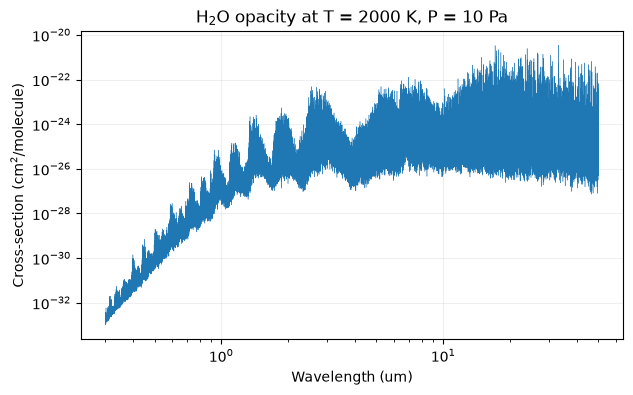

In [4]:
import matplotlib.pyplot as plt
import numpy as np

h2o_xsec = OpacityCache()['H2O']
wlgrid = 10000 / h2o_xsec.wavenumberGrid

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, h2o_xsec.opacity(2000, 1e1), lw=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('Cross-section (cm$^2$/molecule)')
plt.title('H$_2$O opacity at T = 2000 K, P = 10 Pa')
plt.grid(alpha=0.2)